# 실습1. 이진분류 - 피마 인디언 데이터 분석

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FbE10BC%2FbtrK48eVtG7%2FppkpIxk4JGywCIiot8wZf0%2Fimg.jpg">

## 데이터의 샘플, 속성, 클래스와 피처 정보 구조
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FQ2Yjm%2FbtrK46H5hfv%2F5uS8xbfVuqxnrkgpTI63N0%2Fimg.jpg">

### 각 feature(속성)의 의미
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FexNZKP%2FbtrK5xMeR05%2FJpgJHXtxZwsyvk551RsdF0%2Fimg.jpg">


In [ ]:
import os
import warnings

# TensorFlow의 C++ 백엔드 로그 중 INFO, WARNING 메시지를 숨긴다.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# Python에서 발생하는 Warning 메시지를 화면에 출력하지 않는다.
warnings.filterwarnings("ignore")

import tensorflow as tf
print(tf.__version__)

2.21.0


In [10]:
# 설치 안되어 있다면 설치
# uv add seaborn pandas

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 데이터가 없다면 다운로드
# !git clone https://github.com/taehojo/data.git

In [17]:
df = pd.read_csv('./datas_dnn/pima-indians-diabetes3.csv')

In [ ]:
df.head(5)

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   bmi        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   diabetes   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [19]:
# target : diabetes / 0 정상, 1 당뇨 환자
df["diabetes"].value_counts()

diabetes
0    500
1    268
Name: count, dtype: int64

In [20]:
df.describe()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
df.corr()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
pregnant,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plasma,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


## 데이터 분석

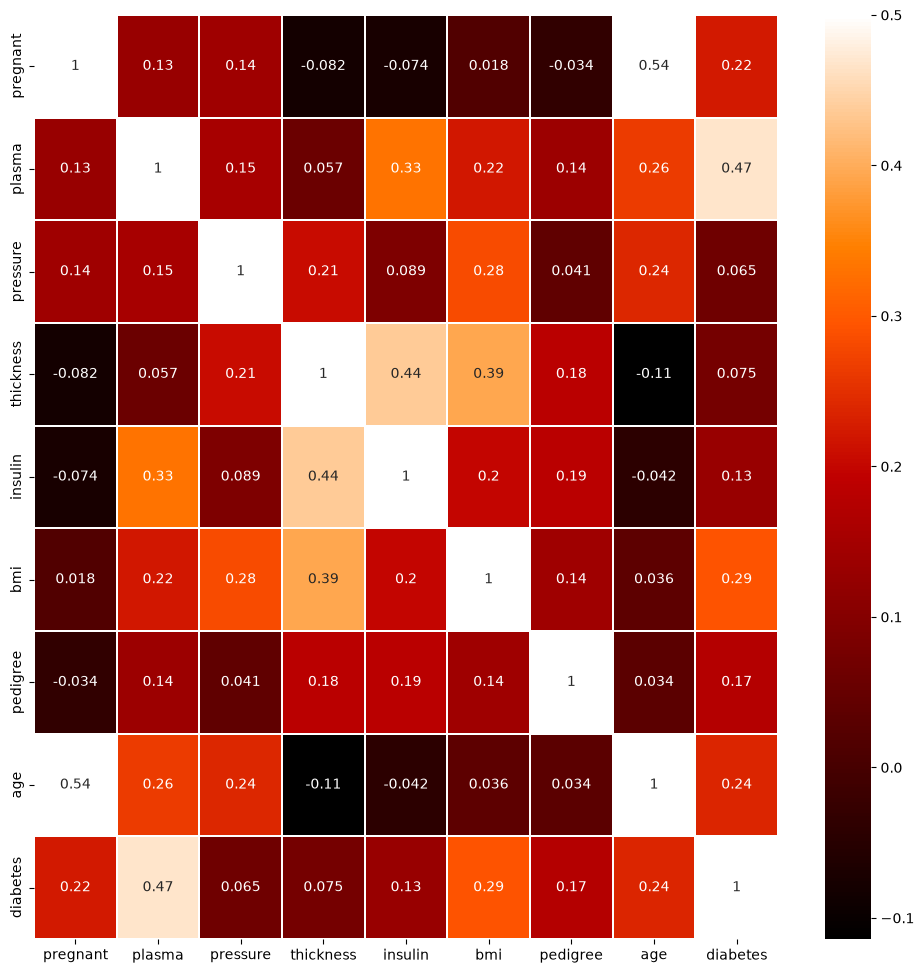

In [22]:
# 데이터 간의 상관 관계를 그래프로 표현해 봅니다.
# colormap 참고 : https://matplotlib.org/2.0.2/users/colormaps.html
colormap = plt.cm.gist_heat   #그래프의 색상 구성을 정합니다.
plt.figure(figsize=(12,12))   #그래프의 크기를 정합니다.

# 그래프의 속성을 결정합니다. vmax의 값을 0.5로 지정해 0.5에 가까울수록 밝은색으로 표시되게 합니다.
sns.heatmap(df.corr(),linewidths=0.1,vmax=0.5, cmap=colormap, linecolor='white', annot=True)
plt.show()

plasma 항목(공복 혈당 농도)과 BMI(체질량 지수)가 우리가 예측하고자 하는 diabetes 항목과 상관관계가 높다는 것을 알 수 있음.  
즉, 이 항목들이 예측 모델을 만드는 데 중요한 역할을 할 것으로 기대할 수 있음  
이제 이 두 항목만 따로 떼어 내어 당뇨의 발병 여부와 어떤 관계가 있는지 알아보자  

## 중요한 데이터 추출

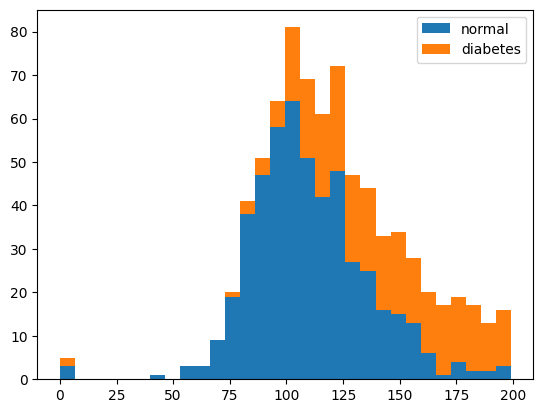

In [ ]:
# plasma : 공복 혈당 농도
plt.hist(x=[df.plasma[df.diabetes==0], df.plasma[df.diabetes==1]], bins=30,
         histtype='barstacked', label=['normal', 'diabetes'])
plt.legend()
plt.show()

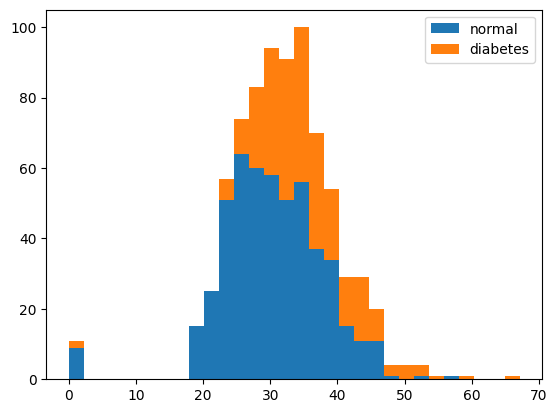

In [ ]:
plt.hist(x=[df.bmi[df.diabetes==0], df.bmi[df.diabetes==1]], bins=30,
         histtype='barstacked', label=['normal', 'diabetes'])
plt.legend()
plt.show()

BMI가 높아질 경우 당뇨의 발병률도 함께 증가하는 추세를 볼 수 있음
이렇게 결과에 미치는 영향이 큰 항목을 발견하는 것이 데이터 전처리 과정 중 하나

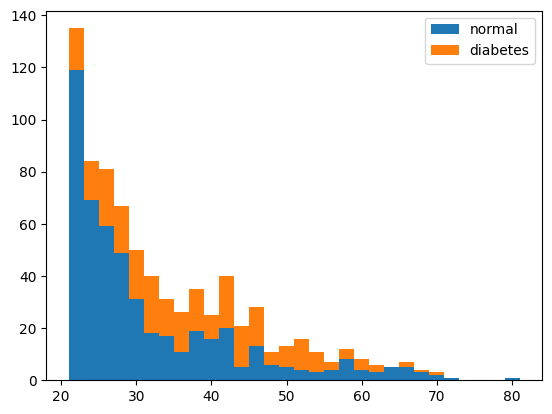

In [ ]:
# 나이를 기준으로 정상과 당뇨의 분포 비율 확인
plt.hist(x=[df.age[df.diabetes==0], df.age[df.diabetes==1]], bins=30,
         histtype='barstacked', label=['normal', 'diabetes'])
plt.legend()
plt.show()

# 피마 인디언의 당뇨병 예측 실행

In [25]:
df = pd.read_csv('./datas_dnn/pima-indians-diabetes3.csv')

X = df.iloc[:, 0:8] # 세부 정보를 X로 지정함
y = df.iloc[:, 8]   # 당뇨병 여부를 y로 지정함

In [28]:
X.head()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [30]:
y[:5]

0    1
1    0
2    1
3    0
4    1
Name: diabetes, dtype: int64

## 모델 구조 설정

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FcbHl20%2FbtrK9x5vkcw%2FMpoiZolocmOOcBLiVTKtzK%2Fimg.jpg">

- feature의 갯수 : 입력 갯수
- 은닉층 노드 : 12, 8 (테스트를 하면서 최적의 값을 찾아야함.)
- 출력 노드 : 1개

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [32]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(12, activation='relu', name='Dense_1'))
model.add(Dense(8, activation='relu', name='Dense_2'))
model.add(Dense(1, activation='sigmoid', name='Dense_3'))
model.summary()

I0000 00:00:1788102777.263473   13682 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1402 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

## 당뇨병 예측 실행

### 대표적인 오차함수
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fx4jvX%2FbtrK2t5phg7%2Fe4ysGzWFdks8dNOAMjzNz1%2Fimg.jpg">

In [33]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [34]:
history = model.fit(X, y, epochs= 100, batch_size=5, verbose='auto')

Epoch 1/100


I0000 00:00:1788102797.991115   15046 service.cc:153] XLA service 0x7f64a8031260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788102797.991154   15046 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1050, Compute Capability 6.1 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788102798.037141   15046 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788102798.268698   15046 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788102798.301802   15046 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1336__.9


  1/154 ━━━━━━━━━━━━━━━━━━━━ 6:14 2s/step - accuracy: 0.2000 - loss: 50.7203

I0000 00:00:1788102799.796299   15046 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1788102797.831928   15046 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1336__.9


154/154 ━━━━━━━━━━━━━━━━━━━━ 1s -6536us/step - accuracy: 0.4570 - loss: 12.5102
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6068 - loss: 1.4173
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6068 - loss: 1.1117
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6250 - loss: 0.9236
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6094 - loss: 0.8673
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6185 - loss: 0.8741
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6589 - loss: 0.7547
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6328 - loss: 0.7539
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6237 - loss: 0.7262
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6667 - loss: 0.6890
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6562 - loss: 0.6835
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

In [ ]:
# 학습 완료 했으면, gpu 메모리 해제, restart kernel